# Bank Marketing - Model Training & EDA

**Problem:** Predict whether a client will subscribe to a term deposit (`y = yes/no`) using the UCI Bank Marketing dataset.

This notebook loads the data, explores basic properties, trains five classifiers with the same preprocessing pipeline as `train.py`, and compares test-set metrics.

In [1]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path("..").resolve() if Path.cwd().name == "model" else Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from model.preprocess import load_raw_bank, prepare_xy

DATA_PATH = ROOT / "data" / "bank-full.csv"
df = load_raw_bank(DATA_PATH)
X, y = prepare_xy(df)
print(f"Loaded {len(df):,} rows from {DATA_PATH.name}")

Loaded 45,211 rows from bank-full.csv


In [2]:
# EDA: shape, target balance, dtypes, leakage note
print("Shape:", df.shape)
print("\nTarget value counts (encoded y):")
print(y.value_counts().rename({0: "no (0)", 1: "yes (1)"}))
print(f"\nPositive class rate: {y.mean():.3f}")
print("\nFeature dtypes:")
print(X.dtypes)
print("\nNote: `duration` is dropped in prepare_xy() - it is only known after the call ends (data leakage).")

Shape: (45211, 17)

Target value counts (encoded y):
y
no (0)     39922
yes (1)     5289
Name: count, dtype: int64

Positive class rate: 0.117

Feature dtypes:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
campaign     int64
pdays        int64
previous     int64
poutcome       str
dtype: object

Note: `duration` is dropped in prepare_xy() - it is only known after the call ends (data leakage).


In [3]:
from sklearn.model_selection import train_test_split

from model.preprocess import (
    build_models,
    build_preprocessor,
    get_feature_columns,
    make_pipeline,
)

numeric_cols, categorical_cols = get_feature_columns(X)
preprocessor = build_preprocessor(numeric_cols, categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\nModels to train: {list(build_models().keys())}")

Train: 36,168  |  Test: 9,043
Numeric features (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Models to train: ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Naive Bayes', 'Random Forest']


In [4]:
from model.preprocess import compute_classification_metrics

rows = []
for name, estimator in build_models().items():
    pipe = make_pipeline(preprocessor, estimator)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    metrics = compute_classification_metrics(y_test, y_pred, y_proba)
    rows.append({"ML Model Name": name, **metrics})

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.rename(
    columns={
        "accuracy": "Accuracy",
        "auc": "AUC",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "mcc": "MCC",
    }
)
metrics_df[["ML Model Name", "Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]]

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.754838,0.772238,0.266236,0.623819,0.373198,0.285345
1,Decision Tree,0.842862,0.608051,0.318681,0.301512,0.309859,0.221381
2,K-Nearest Neighbors,0.887427,0.702749,0.552910,0.197543,0.291086,0.283266
3,Naive Bayes,0.845184,0.751441,0.370846,0.464083,0.412259,0.327093
4,Random Forest,0.878912,0.790262,0.479049,0.399811,0.435858,0.370543


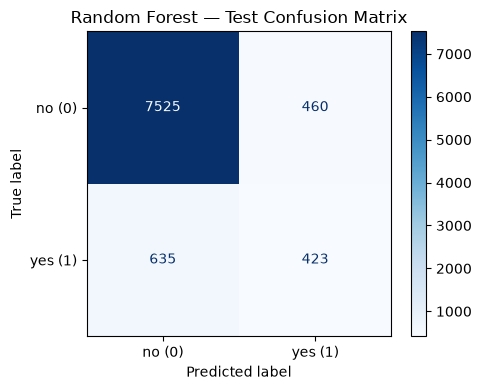

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

rf_pipe = make_pipeline(preprocessor, build_models()["Random Forest"])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["no (0)", "yes (1)"], cmap="Blues", ax=ax
)
ax.set_title("Random Forest - Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Observations

- **Class imbalance:** ~11% positive (`yes`); accuracy alone is misleading - recall, F1, MCC, and AUC matter more.
- **Best AUC:** Logistic Regression (~0.77) and Random Forest (~0.79) rank highest for ranking/subscription probability.
- **Best F1 / MCC:** Random Forest leads on balanced classification metrics among tree/ensemble models.
- **KNN:** High accuracy but very low recall - conservative on predicting `yes`.
- **Decision Tree:** Overfits training patterns; weaker AUC and F1 than Random Forest despite high accuracy.
- **Duration dropped:** Models use only pre-call features, suitable for real campaign targeting before contact length is known.